# Seminar: Portfolio Optimization under Risk constraints

Maximilian Wallhöfer

01/1080254

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.dates as mdates
from sklearn import datasets, linear_model
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import statsmodels.api as sm
from scipy.stats import t
from scipy.optimize import minimize
import os
from statsmodels.tsa.stattools import adfuller
import cvxpy as cp
from tqdm import tqdm
import seaborn as sns

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from pingouin import multivariate_normality
from scipy.stats import gaussian_kde
import openpyxl

### Read Data:
Read in data exported from eikon datastream.
- Period: 01.01.2000 - 01.04.2024

In [ ]:
data_path = "../data/raw/"

In [3]:
return_data = pd.read_excel(data_path + "stock_return_data.xlsx")

In [4]:
# Select only returns

return_df = return_data[['RIC', 'date', 'Total_Return']]

In [5]:
display(return_df)

,RIC,date,Total_Return
0,POOL.OQ,2000-01-31,-6.521010e-10
1,POOL.OQ,2000-02-29,-4.337349e+00
2,POOL.OQ,2000-03-31,2.342569e+01
3,POOL.OQ,2000-04-28,2.020408e+01
4,POOL.OQ,2000-05-31,-7.979626e+00
...,...,...,...
142726,AVY.N,2022-07-31,NaN
142727,AVY.N,2022-12-31,NaN
142728,AVY.N,2023-04-30,NaN
142729,AVY.N,2023-09-30,NaN


## Data Preparation

In [6]:
# Problem: Duplikate in der RIC bei denen ein Wert Daten hat und ein anderer nicht.

def keep_best_of_duplicate_rows(data):
    '''
    Checks for duplicates in the RIC and date and then only keeps the row with the least null values.
    '''
    # Check for duplicates in the 'RIC' column
    duplicate_mask = data.duplicated(subset=['RIC', 'date'], keep=False)
    
    # Create a DataFrame with only duplicated rows
    duplicated_rows = data[duplicate_mask]
    
    duplicated_rows['null_count'] = duplicated_rows.isnull().sum(axis=1)
    
    duplicated_rows_sorted = duplicated_rows.sort_values(by='null_count')
    
    # Keep the rows with the minimal 'null_count' for each unique 'RIC'
    dropped_df = duplicated_rows_sorted.drop_duplicates(subset=['RIC', 'date'], keep='first')
    
    # Get the indexes of the dropped rows to also drop them in data.
    dropped_indexes = duplicated_rows_sorted.index.difference(dropped_df.index)

    # Drop thes indexes in the original data and return.
    cleaned_data = data.drop(dropped_indexes, axis=0)

    return cleaned_data

return_df = keep_best_of_duplicate_rows(return_df)

display(return_df)

,RIC,date,Total_Return
0,POOL.OQ,2000-01-31,-6.521010e-10
1,POOL.OQ,2000-02-29,-4.337349e+00
2,POOL.OQ,2000-03-31,2.342569e+01
3,POOL.OQ,2000-04-28,2.020408e+01
4,POOL.OQ,2000-05-31,-7.979626e+00
...,...,...,...
142726,AVY.N,2022-07-31,NaN
142727,AVY.N,2022-12-31,NaN
142728,AVY.N,2023-04-30,NaN
142729,AVY.N,2023-09-30,NaN


### 1. Investigate missings

C:\Users\maxiw\AppData\Local\Temp\ipykernel_22612\2471804485.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  missings_df['Missing_Count'].fillna(0, inplace=True)


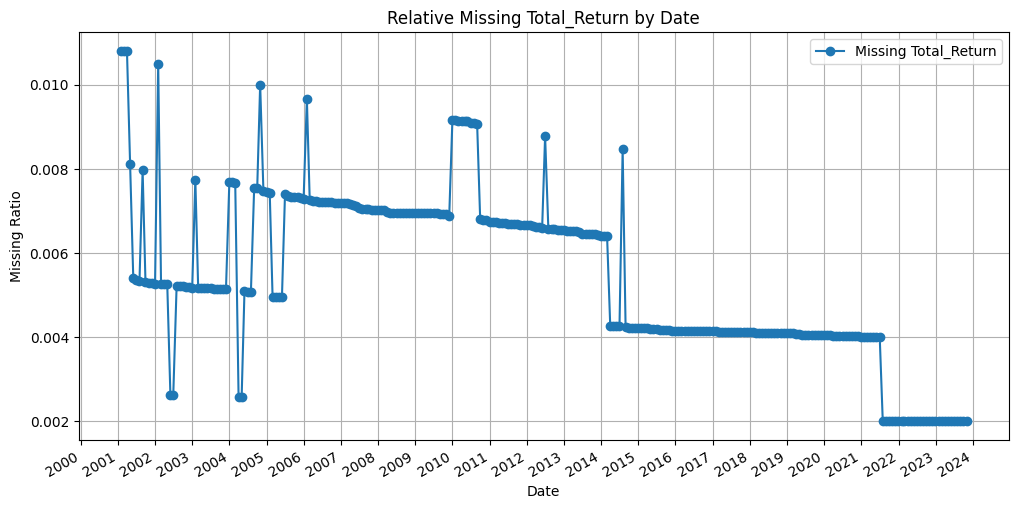

In [7]:
return_df['date'] = pd.to_datetime(return_df['date'])

# Count total and missing values per date
total_counts = return_df.groupby('date')['RIC'].count().reset_index(name='Total_Count')
missing_counts = return_df[return_df['Total_Return'].isnull()].groupby('date')['RIC'].count().reset_index(name='Missing_Count')

# Merge total and missing counts
missings_df = pd.merge(total_counts, missing_counts, on='date', how='left')
missings_df['Missing_Count'].fillna(0, inplace=True)

# Calculate share of missing values
missings_df['Missing_Ratio'] = missings_df['Missing_Count'] / missings_df['Total_Count']

# Filter out dates with 100% missing data
valid_dates = missings_df[missings_df['Missing_Ratio'] < 1.0]

plt.figure(figsize=(12, 6))
plt.plot(valid_dates['date'], valid_dates['Missing_Ratio'], label='Missing Total_Return', marker='o')
plt.title('Relative Missing Total_Return by Date')
plt.xlabel('Date')
plt.ylabel('Missing Ratio')
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.show()

In [8]:
# Exclude invalid dates with 100% missings
valid_dates_list = valid_dates['date']
return_df1 = return_df[return_df['date'].isin(valid_dates_list)].copy()

# Identify the RICs which are never missing

# Count number of missing Total_Return values per RIC
missing_per_ric = return_df1.groupby('RIC')['Total_Return'].apply(lambda x: x.isnull().sum())

rics_no_missing = missing_per_ric[missing_per_ric == 0].index.tolist()

print(f"Number of RICs which have no missing Total_Returns: {len(rics_no_missing)}")

# Select RICs without missings

return_df2 = return_df1[return_df1['RIC'].isin(rics_no_missing)].copy()

display(return_df2)

Number of RICs which have no missing Total_Returns: 486


,RIC,date,Total_Return
12,POOL.OQ,2001-01-31,11.642412
13,POOL.OQ,2001-02-28,-0.931099
14,POOL.OQ,2001-03-30,-2.255639
15,POOL.OQ,2001-04-30,-3.076923
16,POOL.OQ,2001-05-31,7.809524
...,...,...,...
142695,AVY.N,2023-06-30,7.137526
142696,AVY.N,2023-07-31,7.107101
142697,AVY.N,2023-08-31,2.374871
142698,AVY.N,2023-09-29,-2.604373


In [9]:
# Transform into percentage Return by dividing by 100 (Total Return is in absolute Percentages)
print(f"Anzahl Total_Return < -100%: {len(return_df2[return_df2['Total_Return'] < -100])}")

return_df2['return'] = (return_df2['Total_Return'] / 100)
return_df2 = return_df2.drop(columns=['Total_Return'])

display(return_df2)

Anzahl Total_Return < -100%: 0


,RIC,date,return
12,POOL.OQ,2001-01-31,0.116424
13,POOL.OQ,2001-02-28,-0.009311
14,POOL.OQ,2001-03-30,-0.022556
15,POOL.OQ,2001-04-30,-0.030769
16,POOL.OQ,2001-05-31,0.078095
...,...,...,...
142695,AVY.N,2023-06-30,0.071375
142696,AVY.N,2023-07-31,0.071071
142697,AVY.N,2023-08-31,0.023749
142698,AVY.N,2023-09-29,-0.026044


### 2. Check for stationarity

In [10]:
stationarity_results = []

min_obs = 30

# Apply ADF test on returns of every RIC
for ric, group in return_df2.groupby('RIC'):
    series = group.sort_values('date')['return'].dropna()
    
    if len(series) < min_obs:
        print(f"Skipping RIC {ric} due to insufficient observations ({len(series)}).")
        continue

    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    test_stat = result[0]
    is_stationary = p_value < 0.05

    stationarity_results.append({
        'RIC': ric,
        'ADF_statistic': test_stat,
        'p_value': p_value,
        'is_stationary': is_stationary
    })

stationarity_df = pd.DataFrame(stationarity_results)

stationary_rics = stationarity_df[stationarity_df['is_stationary']]['RIC'].tolist()

# Display summary
print(f"Total RICs tested: {len(stationarity_df)}")
print(f"Stationary RICs at 5% level: {len(stationary_rics)}")

Skipping RIC CEG.OQ due to insufficient observations (22).
Skipping RIC GEHC.OQ due to insufficient observations (11).
Skipping RIC KVUE.N due to insufficient observations (6).
Skipping RIC VLTO.N due to insufficient observations (2).
Total RICs tested: 482
Stationary RICs at 5% level: 479


In [11]:
stationarity_df

,RIC,ADF_statistic,p_value,is_stationary
0,A.N,-15.376083,3.456925e-28,True
1,AAL.OQ,-11.015370,6.175996e-20,True
2,AAPL.OQ,-16.225576,3.858201e-29,True
3,ABBV.N,-9.842549,4.711356e-17,True
4,ABNB.OQ,-5.139694,1.165883e-05,True
...,...,...,...,...
477,YUM.N,-7.236902,1.928962e-10,True
478,ZBH.N,-15.948390,7.404616e-29,True
479,ZBRA.OQ,-9.450781,4.622678e-16,True
480,ZION.OQ,-4.397450,2.999328e-04,True


In [12]:
display(stationarity_df[stationarity_df['is_stationary'] == False])

,RIC,ADF_statistic,p_value,is_stationary
315,MTCH.OQ,-2.426877,0.134294,False
345,PAYC.N,-2.253787,0.187306,False
436,UBER.N,-1.837136,0.362187,False


In [13]:
# Exclude non stationary RICs
stationary_return_df = return_df2[return_df2['RIC'].isin(stationary_rics)]
display(stationary_return_df)

,RIC,date,return
12,POOL.OQ,2001-01-31,0.116424
13,POOL.OQ,2001-02-28,-0.009311
14,POOL.OQ,2001-03-30,-0.022556
15,POOL.OQ,2001-04-30,-0.030769
16,POOL.OQ,2001-05-31,0.078095
...,...,...,...
142695,AVY.N,2023-06-30,0.071375
142696,AVY.N,2023-07-31,0.071071
142697,AVY.N,2023-08-31,0.023749
142698,AVY.N,2023-09-29,-0.026044


### 3. Include only permanent constituents

In [19]:
ric_periods['min'].sort_values(ascending=True)

0     2001-01-31
288   2001-01-31
287   2001-01-31
286   2001-01-31
285   2001-01-31
         ...    
118   2019-05-31
26    2019-06-28
77    2020-03-31
340   2020-03-31
4     2020-12-31
Name: min, Length: 479, dtype: datetime64[us]

In [15]:
# Only take constituents of the SP500 which permanently were in it for the whole time horizon

ric_periods = stationary_return_df.groupby('RIC')['date'].agg(['min', 'max']).reset_index()
ric_permanent = ric_periods[ric_periods['min'] == ric_periods['min'].min()]['RIC'].tolist()
print(f"Number of permanent constituents: {len(ric_permanent)}")
display(ric_periods)

Number of permanent constituents: 363


,RIC,min,max
0,A.N,2001-01-31,2023-10-31
1,AAL.OQ,2013-12-31,2023-10-31
2,AAPL.OQ,2001-01-31,2023-10-31
3,ABBV.N,2012-12-31,2023-10-31
4,ABNB.OQ,2020-12-31,2023-10-31
...,...,...,...
474,YUM.N,2001-01-31,2023-10-31
475,ZBH.N,2001-07-31,2023-10-31
476,ZBRA.OQ,2001-01-31,2023-10-31
477,ZION.OQ,2001-01-31,2023-10-31


In [14]:
# Only take constituents of the SP500 which permanently were in it for the whole time horizon

ric_periods = stationary_return_df.groupby('RIC')['date'].agg(['min', 'max']).reset_index()
ric_permanent = ric_periods[ric_periods['min'] == '2000-01-31']['RIC'].tolist()
print(f"Number of permanent constituents: {len(ric_permanent)}")
display(ric_periods)

Number of permanent constituents: 0


,RIC,min,max
0,A.N,2001-01-31,2023-10-31
1,AAL.OQ,2013-12-31,2023-10-31
2,AAPL.OQ,2001-01-31,2023-10-31
3,ABBV.N,2012-12-31,2023-10-31
4,ABNB.OQ,2020-12-31,2023-10-31
...,...,...,...
474,YUM.N,2001-01-31,2023-10-31
475,ZBH.N,2001-07-31,2023-10-31
476,ZBRA.OQ,2001-01-31,2023-10-31
477,ZION.OQ,2001-01-31,2023-10-31


In [39]:
# Filter on permanent constituents.
# Done because longer time horizons are required for efficient bootstrapping.

stationary_return_df1 = stationary_return_df[stationary_return_df['RIC'].isin(ric_permanent)]
display(stationary_return_df1)

,RIC,date,return


In [19]:
# Test for multivariate normal distribution:
# Henze-Zirkler multivariate normality test

return_mat = (
    stationary_return_df1
    .pivot(index="date", columns="RIC", values="return")
    .dropna(axis=0)
)

result = multivariate_normality(return_mat, alpha=0.05)
hz_stat = result[0]
p_value = result[1]
print(f"Henze–Zirkler stat: {hz_stat:.4g},  p-value: {p_value:.4g}")
print("Reject multivariate normality at 5%:", p_value < 0.05)
print(result[2])

Henze–Zirkler stat: 1156,  p-value: 0
Reject multivariate normality at 5%: True
False


## Generate Return Scenarios with Bootstrapping

In [ ]:
# Pivot return data
return_matrix = stationary_return_df1.pivot(index='date', columns='RIC', values='return')
display(return_matrix)

RIC,A.N,AAPL.OQ,ABT.N,ACGL.OQ,ADBE.OQ,ADI.OQ,ADM.N,ADP.OQ,ADSK.OQ,AEE.N,...,WMB.N,WMT.N,WST.N,WY.N,XEL.OQ,XOM.N,XRAY.OQ,YUM.N,ZBRA.OQ,ZION.OQ
date,,,,,,,,,,,,,,,,,,,,,
2000-01-31,-0.143897,0.009119,-0.097065,0.158416,-0.181227,0.005376,-0.035897,-0.119490,-0.092685,-5.725191e-03,...,0.267894,-0.207957,0.005608,-0.195522,-0.012821,0.036462,0.047619,-0.258900,0.011752,0.003960
2000-02-29,0.566572,0.104819,0.003831,0.042735,0.852440,0.679144,-0.139973,-0.081686,0.462168,-7.869482e-02,...,0.079032,-0.110731,-0.048485,-0.105664,-0.087662,-0.092836,0.035354,-0.069869,0.124604,-0.102537
2000-03-31,0.003014,0.184842,0.074427,0.073770,0.091363,0.026274,0.031056,0.109845,0.018182,5.474215e-02,...,0.054239,0.141254,-0.140127,0.110840,0.131673,0.033195,0.109834,0.166667,-0.248826,-0.215548
2000-04-28,-0.147837,-0.086516,0.097600,-0.060115,0.086468,-0.046548,-0.042169,0.115285,-0.155477,1.858586e-01,...,-0.150782,-0.002252,-0.027729,-0.062500,0.116715,-0.001606,0.024229,0.098592,0.140000,-0.003003
2000-05-31,-0.169252,-0.322922,0.058537,-0.025381,-0.069251,0.002441,0.207154,0.020906,-0.030945,-7.407630e-12,...,0.113903,0.040632,-0.038363,-0.064345,0.014327,0.078095,0.055914,-0.141026,-0.157895,0.131392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-29,-0.076402,-0.088678,-0.058795,0.037080,-0.088390,-0.032262,-0.048928,-0.050382,-0.067721,-4.845823e-02,...,-0.011417,-0.016481,-0.077882,-0.063817,0.010451,0.057469,-0.075219,-0.034318,-0.139922,-0.017183
2023-10-31,-0.073692,-0.002570,-0.018228,0.087442,0.043460,-0.101434,-0.051047,-0.092942,-0.044850,1.175999e-02,...,0.021075,0.021760,-0.151702,-0.064253,0.035827,-0.099762,-0.109778,-0.032656,-0.114573,-0.115792
2023-11-30,0.236335,0.113747,0.103014,-0.034495,0.148386,0.165576,0.036457,0.053616,0.105247,2.483159e-02,...,0.069477,-0.047243,0.102681,0.099338,0.026489,-0.020540,0.044064,0.043727,0.131548,0.168970


In [114]:
# Perform bootstrap
return_array = return_matrix.values

# Number of bootstrap scenarios
num_scenarios = 1000

# Set random seed for reproducibility
np.random.seed(42)

# Sample row indices with replacement
sample_indices = np.random.choice(return_array.shape[0], size=num_scenarios, replace=True)

# Generate bootstrapped scenario matrix
scenario_matrix = return_array[sample_indices, :]

loss_matrix = -scenario_matrix

print(scenario_matrix.shape)

(1000, 352)


## Optimization

In [115]:
def compute_shrinkage_covariance(return_df, min_rows=30, max_iter=100, step=0.01, enforce_pd=True):
    """
    Compute a shrinkage covariance matrix from a return DataFrame using a modified Ledoit-Wolf approach.

    Parameters:
    
    return_df : pd.DataFrame
        DataFrame of asset returns with shape (T, N), rows = time, columns = assets
    min_rows : int
        Minimum number of time points required for covariance estimation
    max_iter : int
        Max iterations to adjust shrinkage parameter
    step : float
        Step size for increasing shrinkage
    enforce_pd : bool
        If True, increases shrinkage until matrix is positive definite

    Returns:
    
    shrinkage_cov : pd.DataFrame
        Shrinkage covariance matrix (N x N)
    """

    # Drop rows with any NaNs
    clean_returns = return_df.dropna()
    if clean_returns.shape[0] < min_rows:
        raise ValueError(f"Not enough valid rows for covariance estimation: {clean_returns.shape[0]} < {min_rows}")

    # Sample statistics
    sample_cov = clean_returns.cov()
    sample_mean = clean_returns.mean()
    deviations = clean_returns - sample_mean
    outer_products = deviations.T @ deviations

    # Initial shrinkage parameter
    delta = 1 / len(clean_returns)

    # Define target as diagonal matrix (variance-only)
    target = np.diag(np.diag(outer_products))

    # Shrinkage
    shrinkage_cov = delta * target + (1 - delta) * sample_cov.values
    shrinkage_df = pd.DataFrame(shrinkage_cov, index=sample_cov.index, columns=sample_cov.columns)

    if enforce_pd:
        for i in range(max_iter):
            eigenvalues = np.linalg.eigvalsh(shrinkage_df)
            if np.all(eigenvalues > 0):
                break
            delta = min(delta + step, 1.0)
            shrinkage_cov = delta * target + (1 - delta) * sample_cov.values
            shrinkage_df = pd.DataFrame(shrinkage_cov, index=sample_cov.index, columns=sample_cov.columns)
        else:
            raise RuntimeError("Failed to obtain a positive definite matrix after max_iter.")
    return shrinkage_df

In [116]:
# Compute shrinkage covariance Matrix of scenario returns.

scenario_df = pd.DataFrame(scenario_matrix)
shrinked_cov = compute_shrinkage_covariance(scenario_df)

shrinked_cov.shape

(352, 352)

### 1. Mean Variance Optimization

In [117]:
# scenario_matrix (S scenarios × N assets)
S, N = scenario_matrix.shape

# Empirical mean from scenarios
mu = scenario_matrix.mean(axis=0)

print(S, N)

1000 352


In [118]:
# Upper bound for expected return if there has to be invested at least 20% in every asset

def max_long_only_return(mu, vub=0.20):
    mu = np.asarray(mu)
    n  = len(mu)

    # sort expected returns descending
    mu_sorted = np.sort(mu)[::-1]

    k_full = int(1 // vub)          # number of assets that can take ν without overshooting
    rem    = 1 - k_full * vub       # leftover budget (0 for ν = 0.20)

    ret_full = vub * mu_sorted[:k_full].sum()

    # leftover goes to the next best asset (if any budget remains)
    ret_rem  = rem * mu_sorted[k_full] if rem > 1e-12 and k_full < n else 0.0

    return ret_full + ret_rem

def min_long_only_return(mu, vub=0.20):
    mu = np.asarray(mu)
    n  = len(mu)

    # ascending order -> lowest returns first
    mu_sorted = np.sort(mu)

    k_full = int(1 // vub)          # how many assets can take vub
    rem    = 1 - k_full * vub       # leftover budget (0 if vub = 0.20)

    # invest vub in the k_full worst assets
    ret_full = vub * mu_sorted[:k_full].sum()

    # put any leftover into the next-worst asset
    ret_rem  = rem * mu_sorted[k_full] if rem > 1e-12 and k_full < n else 0.0

    return ret_full + ret_rem



upper_bound = max_long_only_return(mu, vub=0.20)
lower_bound = min_long_only_return(mu, vub=0.20)

print(f"Theoretical upper bound: {upper_bound*100:.2f} %")
print(f"Theoretical lower bound: {lower_bound*100:.2f} %")

Theoretical upper bound: 3.09 %
Theoretical lower bound: 0.35 %


In [119]:
target_returns = np.linspace(lower_bound, upper_bound, 100)

MV_portfolio_risks = []
MV_portfolio_returns = []
MV_weights_list = []

# Loop over target returns and solve quadratic program
for target in tqdm(target_returns, desc="MV portfolios"):
    w = cp.Variable(N)
    
    # Objective: minimize portfolio variance
    portfolio_variance = cp.quad_form(w, shrinked_cov)
    objective = cp.Minimize(portfolio_variance)
    
    # Constraints: full investment, target return
    constraints = [
        cp.sum(w) == 1,
        mu @ w >= target,
        w >= 0,
        w <= 0.20
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    prob.solve()

    if w.value is not None:
        weights = w.value
        MV_weights_list.append(weights)
        MV_portfolio_risks.append(np.sqrt(weights.T @ shrinked_cov @ weights))
        MV_portfolio_returns.append((mu @ weights) * 100)

MV portfolios: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


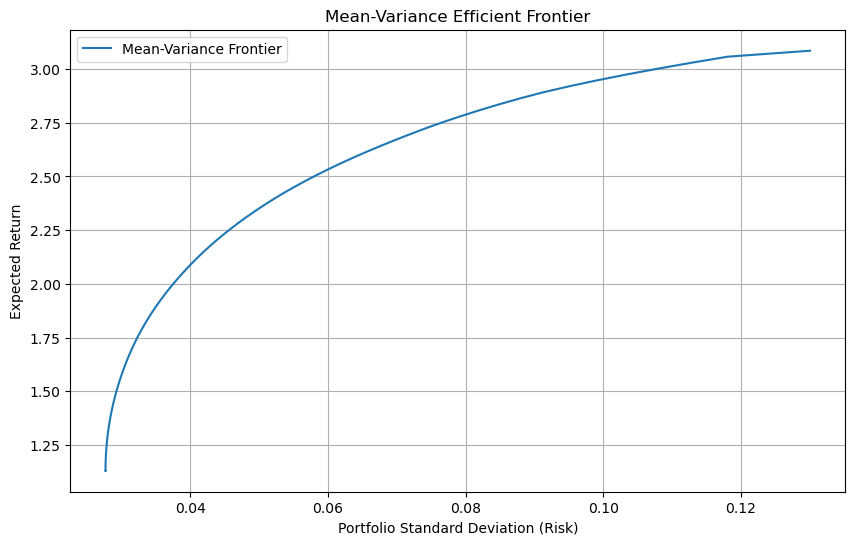

In [202]:
plt.figure(figsize=(10, 6))
plt.plot(MV_portfolio_risks, MV_portfolio_returns, marker='', label='Mean-Variance Frontier')
plt.xlabel('Portfolio Standard Deviation (Risk)')
plt.ylabel('Expected Return')
plt.title('Mean-Variance Efficient Frontier')
plt.grid(True)
plt.legend()
# plt.savefig('Mean_Var_EF.svg', format='svg')
plt.show()

In [223]:
# Set CVar
alpha = 0.9

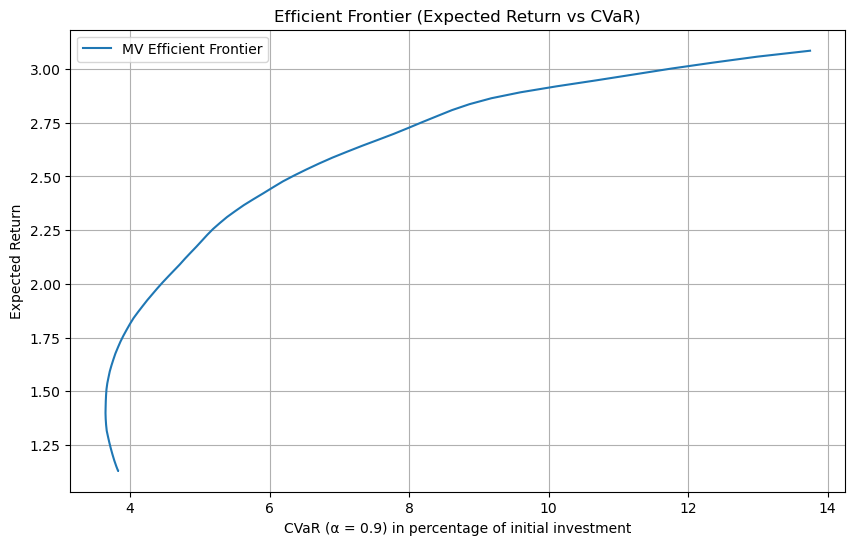

In [224]:
# Compute the corresponding CVaRs
MV_portfolio_cvars = []

def compute_cvar(portfolio_losses, alpha=0.95):
    sorted_losses = np.sort(portfolio_losses)
    k = int(np.ceil(alpha * len(sorted_losses)))
    return sorted_losses[k:].mean()
    
for weights in MV_weights_list:
    portfolio_losses = loss_matrix @ weights
    cvar = compute_cvar(portfolio_losses, alpha=alpha)
    MV_portfolio_cvars.append(cvar * 100)

# Plot: x-axis = CVaR, y-axis = expected return
plt.figure(figsize=(10, 6))
plt.plot(MV_portfolio_cvars, MV_portfolio_returns, label='MV Efficient Frontier', marker='')
plt.xlabel(f'CVaR (α = {alpha}) in percentage of initial investment')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Expected Return vs CVaR)')
plt.grid(True)
plt.legend()
# plt.savefig('Mean_Var_EF_CVaR.svg', format='svg')
plt.show()

In [225]:
MV_portfolio_cvars_min = np.min(MV_portfolio_cvars)
MV_portfolio_cvars_max = np.max(MV_portfolio_cvars)

print(MV_portfolio_cvars_min, MV_portfolio_cvars_max)

3.648237926758581 13.749798725760359


### 2. CVaR constrained Optimization

In [226]:
w = cp.Variable(N)
z = cp.Variable(S)
h = cp.Variable()

cvar_expr = h + (1 / ((1 - alpha) * S)) * cp.sum(z)        # CVaRα(w)

base_constraints = [
    cp.sum(w) == 1,                 # full investment
    w >= 0,
    w <= 0.20,
    z >= 0,
    z >= loss_matrix @ w - h        # z_s ≥ L_s(w) - h
]

prob_min = cp.Problem(cp.Minimize(cvar_expr), base_constraints)
beta_min = prob_min.solve(solver=cp.ECOS, warm_start=True)

w_max = cp.Variable(N)
prob_max = cp.Problem(cp.Maximize(mu @ w_max),
                      [cp.sum(w_max)==1, w_max>=0, w_max<=0.20])
prob_max.solve()
beta_max = compute_cvar(loss_matrix @ w_max.value, alpha)

print(f"β_min  = {beta_min : .6f}")
print(f"β_max  = {beta_max : .6f}")

C:\Users\maxiw\anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


β_min  =  0.029533
β_max  =  0.137498


In [227]:
cvar_portfolio_cvars   = []   # x-axis  (CVaR, in %)
cvar_portfolio_returns = []   # y-axis  (E[return], in %)
cvar_weights_list      = []   # store optimal weights
cvar_constraints       = []   # the β that was imposed (in %)

beta_grid = np.linspace(beta_min, beta_max, 100)


w = cp.Variable(N)
z = cp.Variable(S)
h = cp.Variable()
beta_par = cp.Parameter(nonneg=True)

losses = loss_matrix @ w
constraints = [
    cp.sum(w) == 1,
    w >= 0,            # long only
    w <= 0.20,         # 20 % box
    z >= 0,
    z >= losses - h,
    h + (1/((1-alpha)*S))*cp.sum(z) <= beta_par
]
prob = cp.Problem(cp.Maximize(mu @ w), constraints)

for beta in tqdm(beta_grid, desc="CVaR portfolios"):
    beta_par.value = beta
    prob.solve(solver=cp.ECOS, warm_start=True)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        continue      # skip infeasible

    weights          = w.value
    portfolio_cvar   = compute_cvar(loss_matrix @ weights, alpha)
    portfolio_return = mu @ weights                              

    
    cvar_portfolio_cvars.append(portfolio_cvar * 100)
    cvar_portfolio_returns.append(portfolio_return * 100)
    cvar_weights_list.append(weights)
    cvar_constraints.append(beta * 100)

CVaR portfolios: 100%|██████████| 100/100 [21:39<00:00, 12.99s/it]


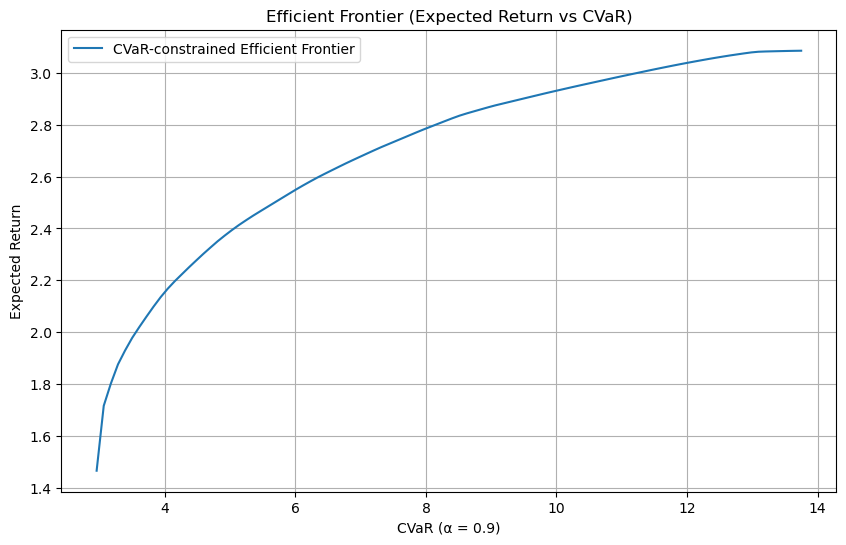

In [228]:
# Plot: x-axis = CVaR, y-axis = expected return
plt.figure(figsize=(10, 6))
plt.plot(cvar_portfolio_cvars, cvar_portfolio_returns, label='CVaR-constrained Efficient Frontier', marker='')
plt.xlabel(f'CVaR (α = {alpha})')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Expected Return vs CVaR)')
plt.grid(True)
plt.legend()
# plt.savefig('CVaR_constrained_EF_CVaR.svg', format='svg')
plt.show()

### 3. Comparing Efficient Frontiers

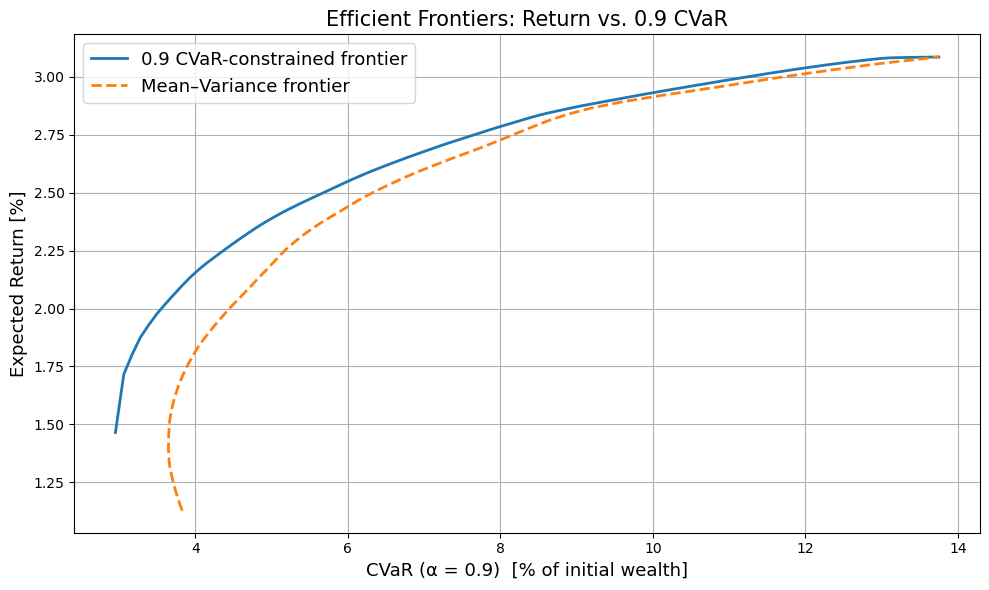

In [229]:
MV_x, MV_y = MV_portfolio_cvars, MV_portfolio_returns
CV_x, CV_y = cvar_portfolio_cvars, cvar_portfolio_returns

plt.figure(figsize=(10, 6))

# CVaR-constrained frontier
plt.plot(CV_x, CV_y,
         label=f"{alpha} CVaR-constrained frontier",
         linewidth=2.0, marker="", markersize=4)

# Mean-Variance frontier
plt.plot(MV_x, MV_y,
         label="Mean–Variance frontier",
         linewidth=2.0, linestyle="--")

plt.xlabel(f"CVaR (α = {alpha})  [% of initial wealth]", fontsize=13)
plt.ylabel("Expected Return [%]", fontsize=13)
plt.title(f"Efficient Frontiers: Return vs. {alpha} CVaR", fontsize=15)

plt.legend(prop={'size': 13})
plt.grid(True)
plt.tight_layout()
plt.savefig(f"Efficient_Frontier_Return_vs_{alpha}CVaR.pdf", format="pdf")
plt.show()

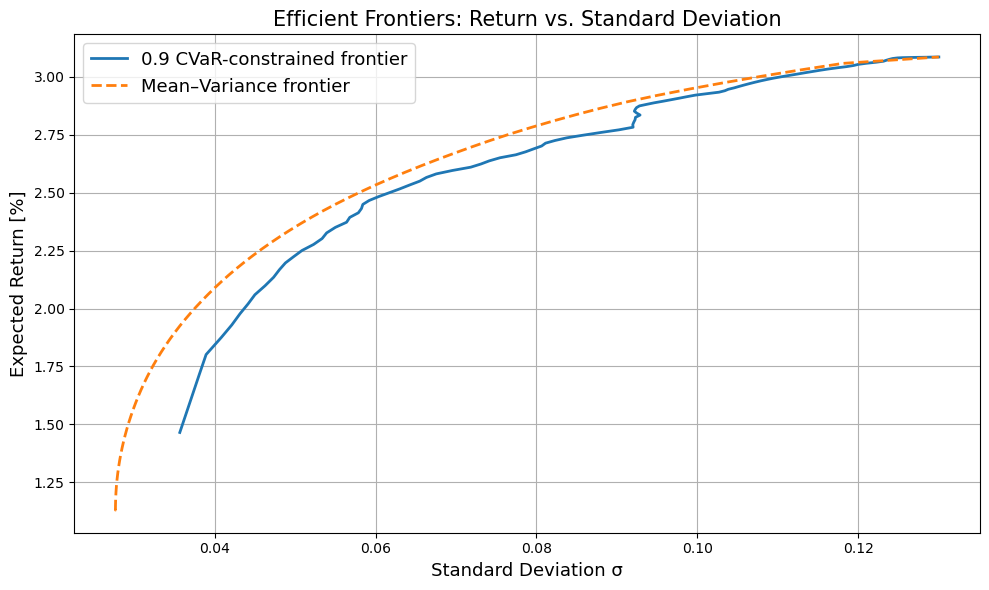

In [230]:
MV_std = [np.sqrt(w.T @ shrinked_cov @ w)
          for w in MV_weights_list]

CV_std = [np.sqrt(w.T @ shrinked_cov @ w)
          for w in cvar_weights_list]

MV_y = MV_portfolio_returns          
CV_y = cvar_portfolio_returns

plt.figure(figsize=(10, 6))

plt.plot(CV_std, CV_y,
         label=f"{alpha} CVaR-constrained frontier",
         linewidth=2.0)

plt.plot(MV_std, MV_y,
         label="Mean–Variance frontier",
         linewidth=2.0, linestyle="--")

plt.xlabel("Standard Deviation σ", fontsize=13)
plt.ylabel("Expected Return [%]",  fontsize=13)
plt.title("Efficient Frontiers: Return vs. Standard Deviation", fontsize=15)

plt.legend(prop={'size': 13})
plt.grid(True)
plt.tight_layout()
plt.savefig(f"Efficient_Frontier_Return_vs_StdDev_{alpha}CVaR.pdf", format="pdf")
plt.show()

## Analyze Loss Distributions of optimal Portfolios

In [231]:
def compute_cvar(portfolio_losses, alpha=0.95):
    sorted_losses = np.sort(portfolio_losses)
    k = int(np.ceil(alpha * len(sorted_losses)))
    return sorted_losses[k:].mean()

def compute_var(portfolio_losses, alpha=0.95):
    sorted_losses = np.sort(portfolio_losses)
    k = int(np.ceil(alpha * len(sorted_losses)))
    return sorted_losses[k -1]

In [232]:
# 1. CVaR-optimal: max return per unit of CVaR
cvar_efficiency = np.array(cvar_portfolio_returns) / np.array(cvar_portfolio_cvars)
idx_cvar_best = np.argmax(cvar_efficiency)

# 2. MV-optimal: max Sharpe ratio
mv_sharpe = np.array(MV_portfolio_returns) / np.array(MV_portfolio_risks)
idx_mv_best = np.argmax(mv_sharpe)

# Best weights
w_cvar = cvar_weights_list[idx_cvar_best]
w_mv   = MV_weights_list[idx_mv_best]

# Portfolio losses in absolute percentage
losses_cvar = loss_matrix @ w_cvar *100
losses_mv   = loss_matrix @ w_mv *100

returns_cvar = - losses_cvar
returns_mv   = - losses_mv

In [233]:
# Get the cvar values:

cvar_cvar = cvar_portfolio_cvars[idx_cvar_best]
var_cvar = compute_var(losses_cvar, alpha)

cvar_mv = MV_portfolio_cvars[idx_mv_best]
var_mv = compute_var(losses_mv, alpha)

print(f"VaRs of MV: {var_mv} and CVaR-constrained: {var_cvar}")
print(f"CVaRs of MV: {cvar_mv} and CVaR-constrained: {cvar_cvar}")

return_cvar = cvar_portfolio_returns[idx_cvar_best]

return_mv = MV_portfolio_returns[idx_mv_best]
print(f"Expected Returns of MV: {return_mv} and CVaR-constrained: {return_cvar}")

VaRs of MV: 2.1423349744464573 and CVaR-constrained: 1.9939101314189103
CVaRs of MV: 3.999022881859729 and CVaR-constrained: 3.280450801549619
Expected Returns of MV: 1.8137151388979293 and CVaR-constrained: 1.87535973413435


In [234]:
idx_cvar_best

3

In [235]:
idx_mv_best

53

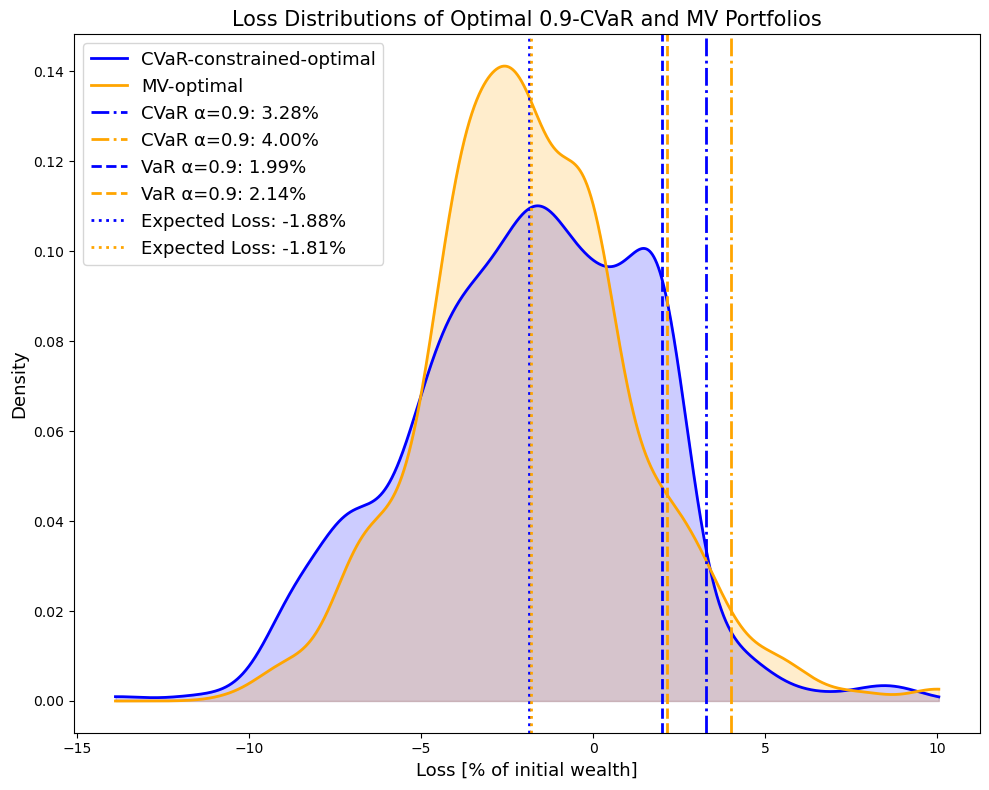

In [236]:
all_losses = np.concatenate([losses_cvar, losses_mv])
x_min = np.min(all_losses)
x_max = np.max(all_losses)
x_grid = np.linspace(x_min, x_max, 3000)

kde_cvar = gaussian_kde(losses_cvar, bw_method=0.25)
kde_mv   = gaussian_kde(losses_mv, bw_method=0.25)

plt.figure(figsize=(10, 8))
plt.plot(x_grid, kde_cvar(x_grid), label="CVaR-constrained-optimal", color='blue', linewidth=2)
plt.plot(x_grid, kde_mv(x_grid),   label="MV-optimal", color='orange', linewidth=2)

plt.axvline(cvar_cvar, color='blue', linestyle='-.', linewidth=2, label=f"CVaR α={alpha}: {cvar_cvar:.2f}%")
plt.axvline(cvar_mv, color='orange', linestyle='-.', linewidth=2, label=f"CVaR α={alpha}: {cvar_mv:.2f}%")

plt.axvline(var_cvar, color='blue', linestyle='--', linewidth=2, label=f"VaR α={alpha}: {var_cvar:.2f}%")
plt.axvline(var_mv, color='orange', linestyle='--', linewidth=2, label=f"VaR α={alpha}: {var_mv:.2f}%")

plt.axvline(-return_cvar, color='blue', linestyle=':', linewidth=2, label=f"Expected Loss: {-return_cvar:.2f}%")
plt.axvline(-return_mv, color='orange', linestyle=':', linewidth=2, label=f"Expected Loss: {-return_mv:.2f}%")

plt.fill_between(x_grid, kde_cvar(x_grid), alpha=0.2, color='blue')
plt.fill_between(x_grid, kde_mv(x_grid), alpha=0.2, color='orange')
plt.xlabel("Loss [% of initial wealth]", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title(f"Loss Distributions of Optimal {alpha}-CVaR and MV Portfolios", fontsize=15)
plt.legend(prop={'size': 13})
plt.grid(False)
plt.tight_layout()
plt.savefig(f"Loss_Distributions_MV_and_{alpha}CVaR.pdf", format="pdf")
plt.show()

## Analyze Diversification of optimal Portfolios

In [237]:
# Threshold to consider a weight as non-zero
threshold = 1e-8

# CVaR portfolio metrics
cvar_div_index = [np.sum(w**2) for w in cvar_weights_list]
cvar_eff_assets = [1/idx if idx > 0 else 0 for idx in cvar_div_index]
cvar_nonzero = [np.sum(w > threshold) for w in cvar_weights_list]

# MV portfolio metrics
mv_div_index = [np.sum(w**2) for w in MV_weights_list]
mv_eff_assets = [1/idx if idx > 0 else 0 for idx in mv_div_index]
mv_nonzero = [np.sum(w > threshold) for w in MV_weights_list]

df_cvar_div = pd.DataFrame({
    'Herfindahl Index': cvar_div_index,
    'Effective Assets': cvar_eff_assets,
    'Non-zero Weights': cvar_nonzero,
    'CVaR (%)': cvar_portfolio_cvars,
    'Expected Return (%)': cvar_portfolio_returns
})

df_mv_div = pd.DataFrame({
    'Herfindahl Index': mv_div_index,
    'Effective Assets': mv_eff_assets,
    'Non-zero Weights': mv_nonzero,
    'CVaR (%)': MV_portfolio_cvars,
    'Expected Return (%)': MV_portfolio_returns
})

# Display sample
display(df_cvar_div)
display(df_mv_div)

,Herfindahl Index,Effective Assets,Non-zero Weights,CVaR (%),Expected Return (%)
0,0.063501,15.747789,27,2.953284,1.465131
1,0.071233,14.038343,21,3.062339,1.715679
2,0.076683,13.040704,20,3.171395,1.801389
3,0.090506,11.049034,23,3.280451,1.875360
4,0.096887,10.321292,21,3.389507,1.929150
...,...,...,...,...,...
95,0.183178,5.459164,7,13.313575,3.083198
96,0.186909,5.350190,7,13.422631,3.083842
97,0.191969,5.209184,7,13.531687,3.084466
98,0.195842,5.106146,6,13.640742,3.084986


,Herfindahl Index,Effective Assets,Non-zero Weights,CVaR (%),Expected Return (%)
0,0.023449,42.646271,131,3.827543,1.130295
1,0.023449,42.646173,127,3.827542,1.130295
2,0.023449,42.646054,126,3.827540,1.130296
3,0.023449,42.645908,125,3.827538,1.130296
4,0.023449,42.645728,125,3.827535,1.130296
...,...,...,...,...,...
95,0.153427,6.517777,9,11.222529,2.974822
96,0.154978,6.452536,8,11.763461,3.002467
97,0.160614,6.226112,8,12.360661,3.030113
98,0.170335,5.870792,8,12.993040,3.057758


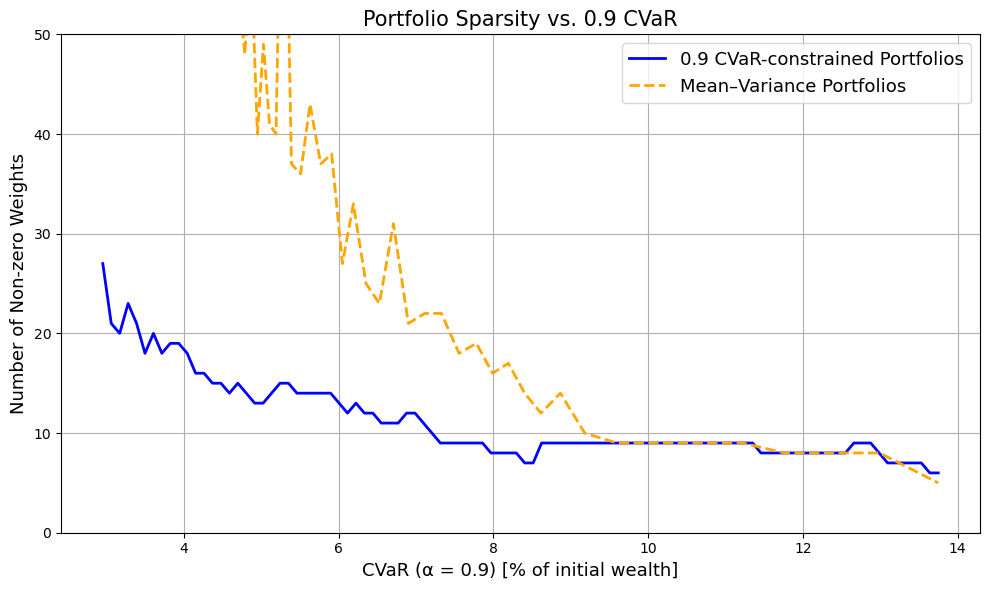

In [238]:
plt.figure(figsize=(10, 6))

# Plot for CVaR-constrained portfolios
plt.plot(cvar_portfolio_cvars, cvar_nonzero, label=f"{alpha} CVaR-constrained Portfolios", linewidth=2, color="blue")

# Plot for MV portfolios
plt.plot(MV_portfolio_cvars, mv_nonzero, label="Mean–Variance Portfolios", linewidth=2, linestyle="--", color="orange")

# Labels and formatting
plt.xlabel(f"CVaR (α = {alpha}) [% of initial wealth]", fontsize=13)
plt.ylabel("Number of Non-zero Weights", fontsize=13)
plt.ylim(0,50)
plt.title(f"Portfolio Sparsity vs. {alpha} CVaR", fontsize=15)
plt.grid(True)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig(f"Portfolio_Sparsity_MV_and_{alpha}CVaR.pdf", format="pdf")
plt.show()